In [127]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import cv2
import os

In [128]:
GT_DIR = os.path.join("images", "ground_truth")
ALGO_DIR = os.path.join("images", "algorithms")

In [129]:
def load_images_from_folder(folder_path):
    images = []
    filenames = []
    for filename in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
            filenames.append(filename)
    return images, filenames

In [130]:
def prepare_data_for_roc(gt_images, algo_images, binarization_threshold = 127):
    gt_array = np.array(gt_images)
    algo_array = np.array(algo_images)
    
    gt_flat = gt_array.flatten()
    algo_flat = algo_array.flatten()
    
    y_true = (gt_flat > binarization_threshold).astype(int) 
    
    y_scores = algo_flat / 255.0
    
    return y_true, y_scores

In [131]:
def calculate_roc_manual(y_true, y_scores):
    thresholds = np.unique(y_scores)[::-1]
    thresholds = np.insert(thresholds, 0, thresholds[0] + 0.1)
    tpr_list = []
    fpr_list = []
    
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    
    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        
        FP = np.sum((y_pred == 1) & (y_true == 0))
        
        TPR = TP / P if P > 0 else 0
        FPR = FP / N if N > 0 else 0
        
        tpr_list.append(TPR)
        fpr_list.append(FPR)
        
    return np.array(fpr_list), np.array(tpr_list), thresholds

In [132]:
def calculate_auc_manual(fpr, tpr):
    auc = 0
    for i in range(1, len(fpr)):
        width = fpr[i] - fpr[i-1]
        avg_height = (tpr[i] + tpr[i-1]) / 2.0
        auc += width * avg_height
        
    return auc

In [133]:
def calculate_jaccard_dice_manual(y_true, y_scores, best_thresh):
    y_pred = (y_scores >= best_thresh).astype(int)
    
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    
    jaccard = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0
    dice = (2 * TP) / ((2 * TP) + FP + FN) if ((2 * TP) + FP + FN) > 0 else 0.0
    
    return jaccard, dice

In [134]:
def plot_roc_curve(title, y_true, y_scores, auc_manual, auc_sklearn, fpr_manual, tpr_manual, fpr_sklearn, tpr_sklearn, best_thresh, optimal_idx, output_jaccard_and_dice):
    print(f"--- {title} ---")
    print(f"Manual AUC: {auc_manual:.4f}")
    print(f"Sklearn AUC: {auc_sklearn:.4f}")
    print(f"Best Threshold: {best_thresh:.4f}")
    if output_jaccard_and_dice:
        jaccard_index, dice_coeffient = calculate_jaccard_dice_manual(y_true, y_scores, best_thresh)
        print(f"Jaccard Index: {jaccard_index:.4f}")
        print(f"Dice Coeffient: {dice_coeffient:.4f}")
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_manual, tpr_manual, color='blue', lw=5, alpha=0.5, 
             label=f'Manual ROC (AUC = {auc_manual:.4f})')
    plt.plot(fpr_sklearn, tpr_sklearn, color='red', lw=2, linestyle='--', 
             label=f'Sklearn ROC (AUC = {auc_sklearn:.4f})')
    plt.plot(fpr_manual[optimal_idx], tpr_manual[optimal_idx], marker='o', 
             color='green', markersize=8, label=f'Best Threshold ({best_thresh:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve: {title}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

In [135]:
def evaluate_and_plot(y_true, y_scores, title, output_jaccard_and_dice):
    fpr_manual, tpr_manual, thresholds = calculate_roc_manual(y_true, y_scores)
    auc_manual = calculate_auc_manual(fpr_manual, tpr_manual)
    
    optimal_idx = np.argmax(tpr_manual - fpr_manual)
    best_thresh = thresholds[optimal_idx]
    
    fpr_sklearn, tpr_sklearn, _ = roc_curve(y_true, y_scores)
    auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

    plot_roc_curve(title, y_true, y_scores, auc_manual, auc_sklearn, fpr_manual, tpr_manual, fpr_sklearn, tpr_sklearn, best_thresh, optimal_idx, output_jaccard_and_dice)

In [136]:
def evaluate_algorithms(gt_path, algo_path, algo_name):    
    gt_images, gt_filenames = load_images_from_folder(gt_path)
    algo_images, _ = load_images_from_folder(algo_path)
    
    if len(gt_images) == 0 or len(algo_images) == 0:
        return
        
    print(f"{'='*50}")
    print(f"{'-'*15} {algo_name} evaluation {'-'*15}")
    print(f"{'='*50}\n")

    print(">>> per-image evaluation <<<\n")
    for gt_img, algo_img, filename in zip(gt_images, algo_images, gt_filenames):
        y_true_img, y_scores_img = prepare_data_for_roc([gt_img], [algo_img])
        
        if np.sum(y_true_img) == 0:
            print(f"--- can't plot roc curve for image {filename} ---")
            continue
            
        evaluate_and_plot(y_true_img, y_scores_img, f"image {filename} - {algo_name}", False)


    print(f"{'='*50}")
    print(f">>> per-algorithm evaluation for {algo_name} <<<")
    print(f"{'='*50}\n")
    
    y_true_all, y_scores_all = prepare_data_for_roc(gt_images, algo_images)
    evaluate_and_plot(y_true_all, y_scores_all, f" overall - {algo_name} evaluation", True)

--------------- alg1 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg1 ---
Manual AUC: 0.7488
Sklearn AUC: 0.7488
Best Threshold: 0.0039


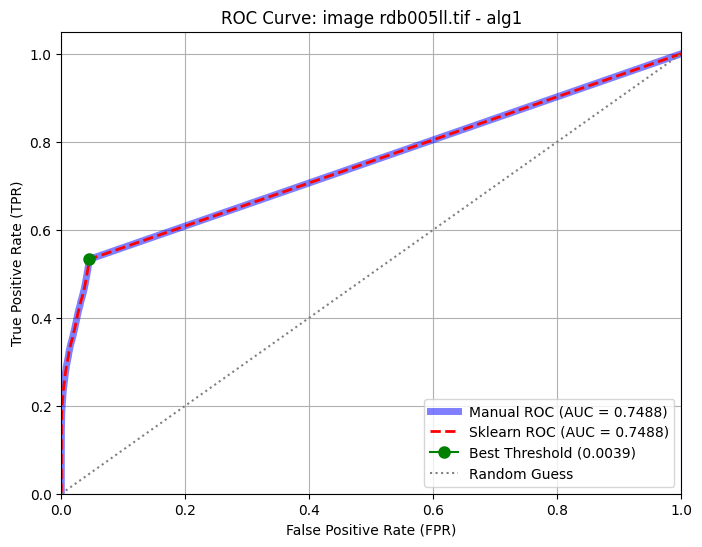

--- image rdb023ll.tif - alg1 ---
Manual AUC: 0.4586
Sklearn AUC: 0.4586
Best Threshold: 0.7471


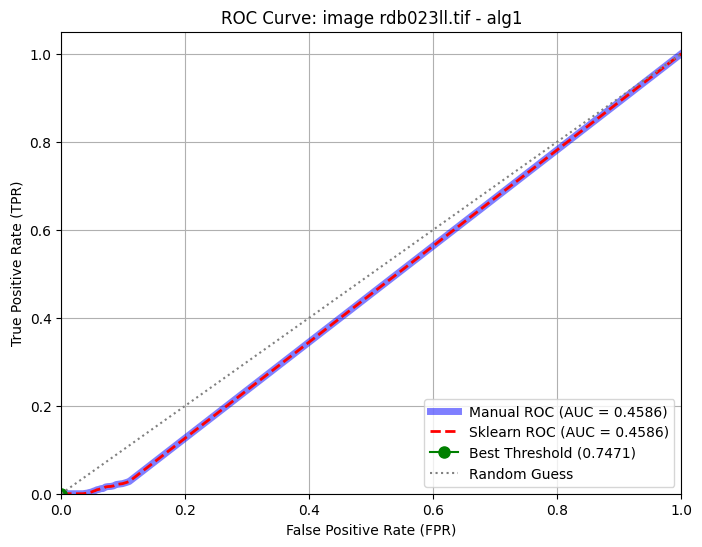

--- image rdb025ll.tif - alg1 ---
Manual AUC: 0.8393
Sklearn AUC: 0.8393
Best Threshold: 0.0039


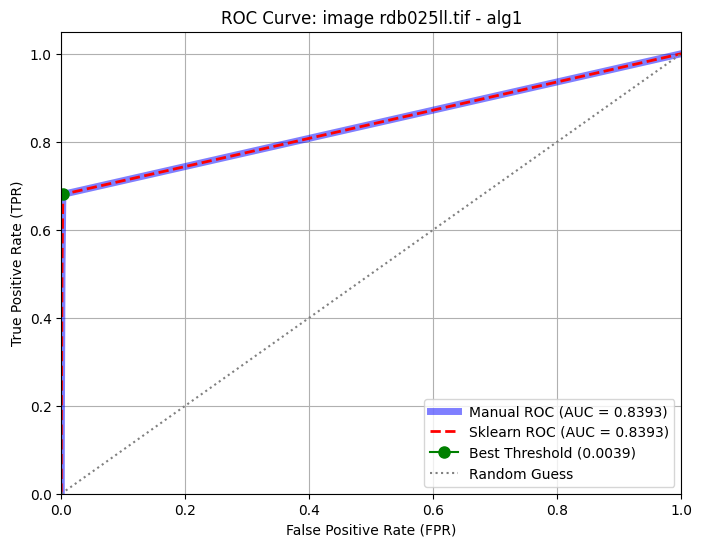

--- image rdb028rl.tif - alg1 ---
Manual AUC: 0.8632
Sklearn AUC: 0.8632
Best Threshold: 0.0039


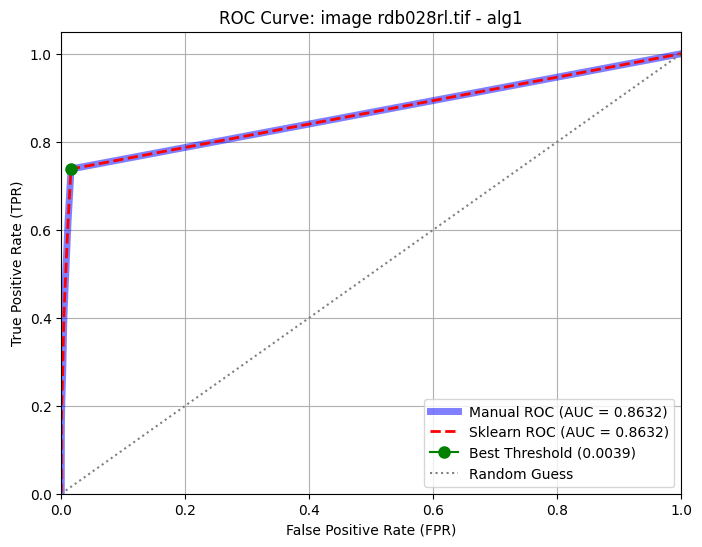

>>> per-algorithm evaluation for alg1 <<<

---  overall - alg1 evaluation ---
Manual AUC: 0.7906
Sklearn AUC: 0.7906
Best Threshold: 0.0039
Jaccard Index: 0.1324
Dice Coeffient: 0.2338


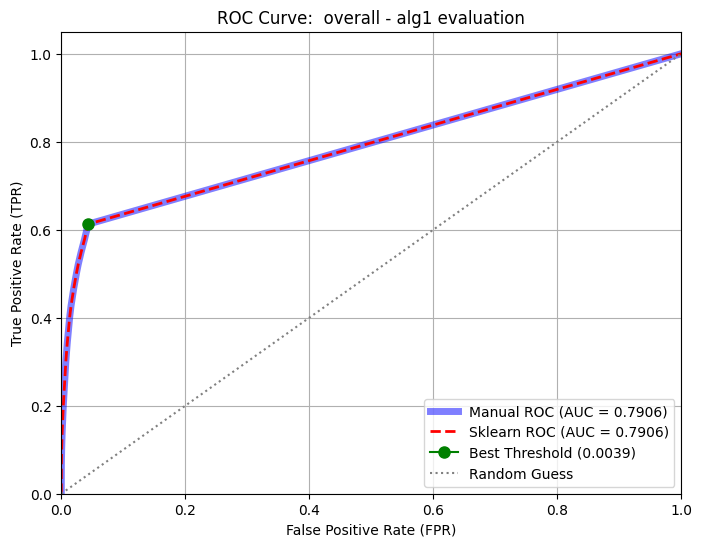

--------------- alg2 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg2 ---
Manual AUC: 0.8645
Sklearn AUC: 0.8645
Best Threshold: 0.2588


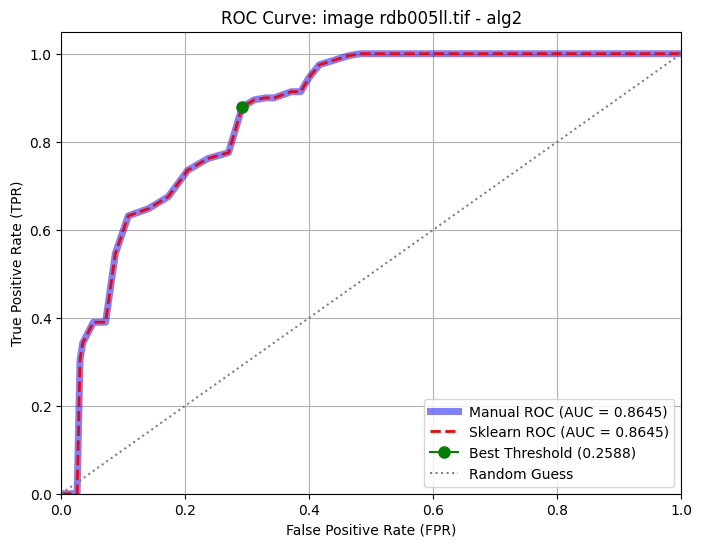

--- image rdb023ll.tif - alg2 ---
Manual AUC: 0.9669
Sklearn AUC: 0.9669
Best Threshold: 0.4196


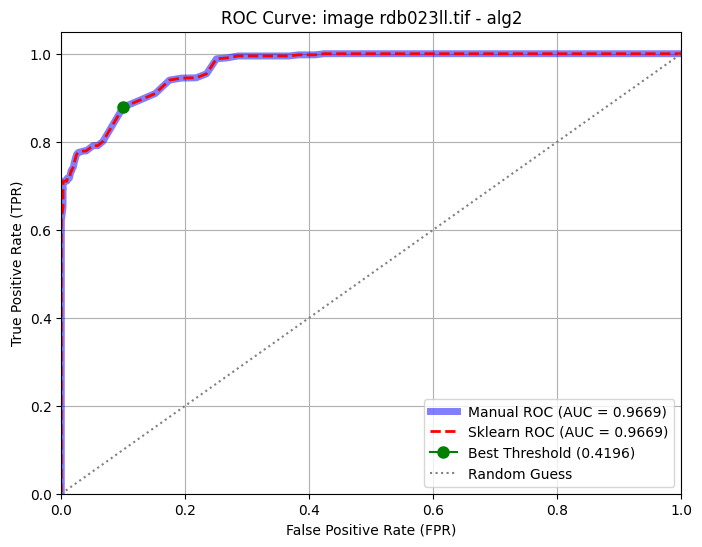

--- image rdb025ll.tif - alg2 ---
Manual AUC: 0.8373
Sklearn AUC: 0.8373
Best Threshold: 0.3608


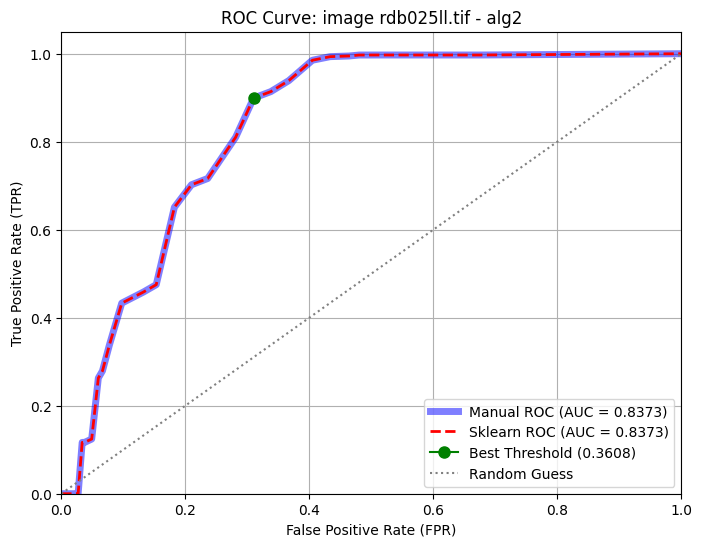

--- image rdb028rl.tif - alg2 ---
Manual AUC: 0.9075
Sklearn AUC: 0.9075
Best Threshold: 0.3804


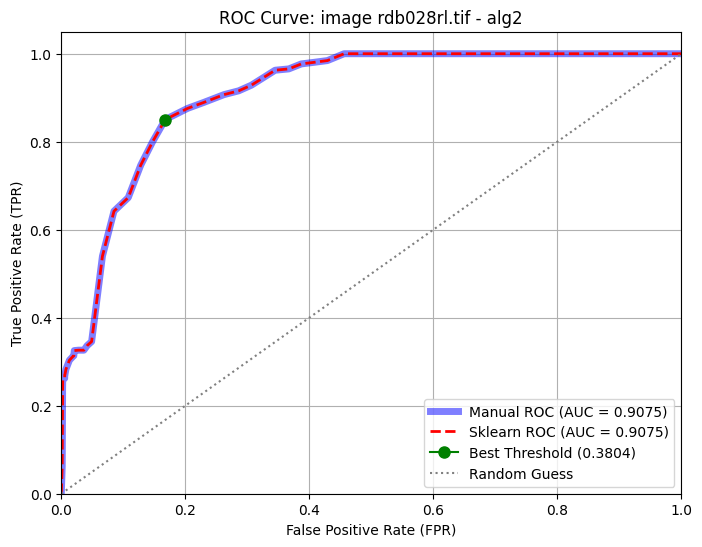

>>> per-algorithm evaluation for alg2 <<<

---  overall - alg2 evaluation ---
Manual AUC: 0.8772
Sklearn AUC: 0.8772
Best Threshold: 0.3216
Jaccard Index: 0.0357
Dice Coeffient: 0.0689


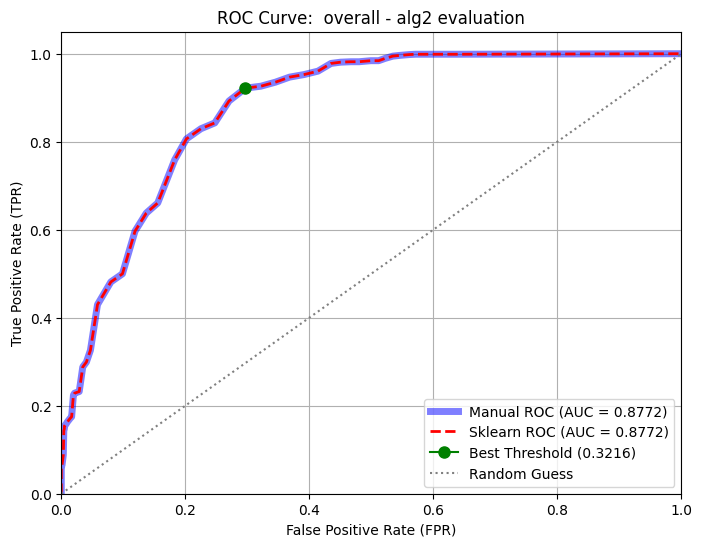

--------------- alg3 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg3 ---
Manual AUC: 0.9482
Sklearn AUC: 0.9482
Best Threshold: 0.0353


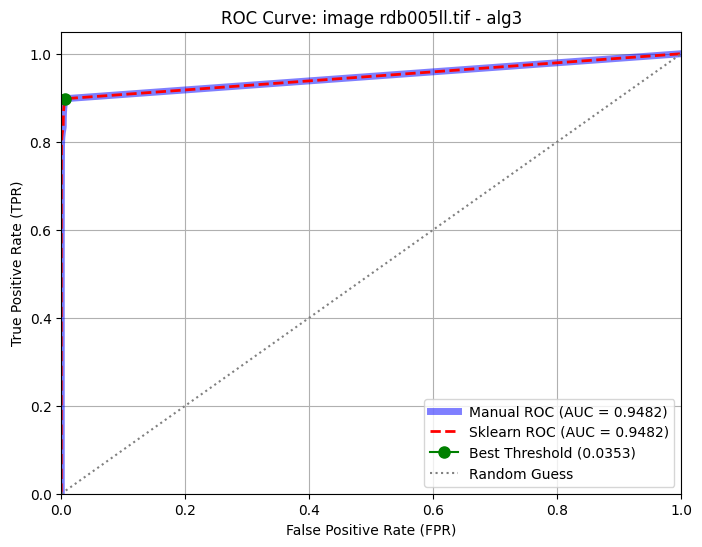

--- image rdb023ll.tif - alg3 ---
Manual AUC: 0.5000
Sklearn AUC: 0.5000
Best Threshold: 0.1000


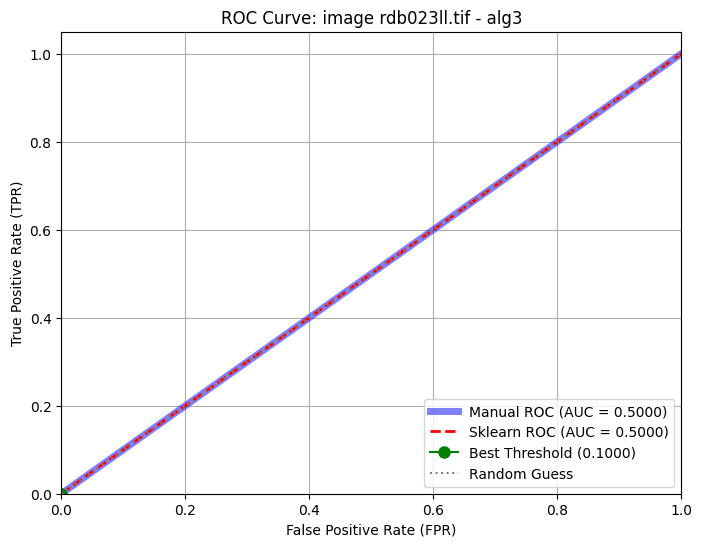

--- image rdb025ll.tif - alg3 ---
Manual AUC: 0.8822
Sklearn AUC: 0.8822
Best Threshold: 0.0196


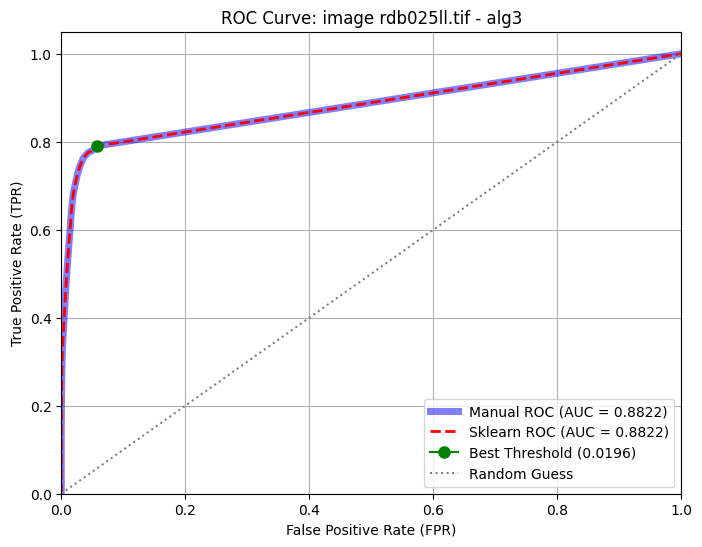

--- image rdb028rl.tif - alg3 ---
Manual AUC: 0.9485
Sklearn AUC: 0.9485
Best Threshold: 0.0353


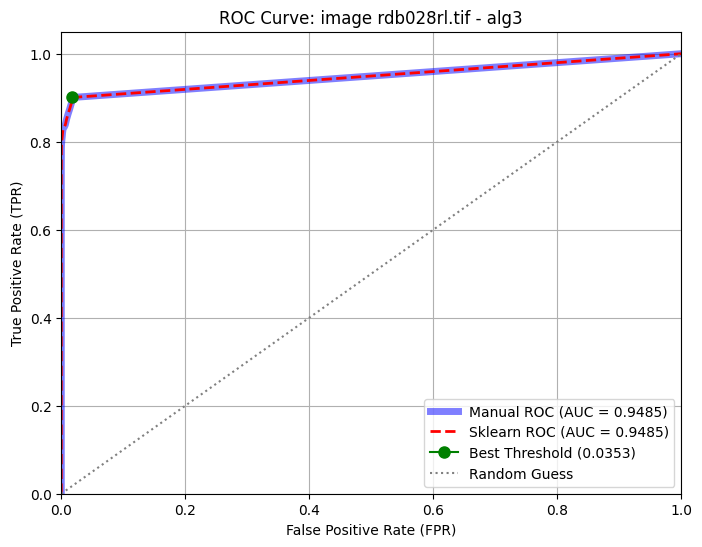

>>> per-algorithm evaluation for alg3 <<<

---  overall - alg3 evaluation ---
Manual AUC: 0.8812
Sklearn AUC: 0.8812
Best Threshold: 0.0196
Jaccard Index: 0.2687
Dice Coeffient: 0.4235


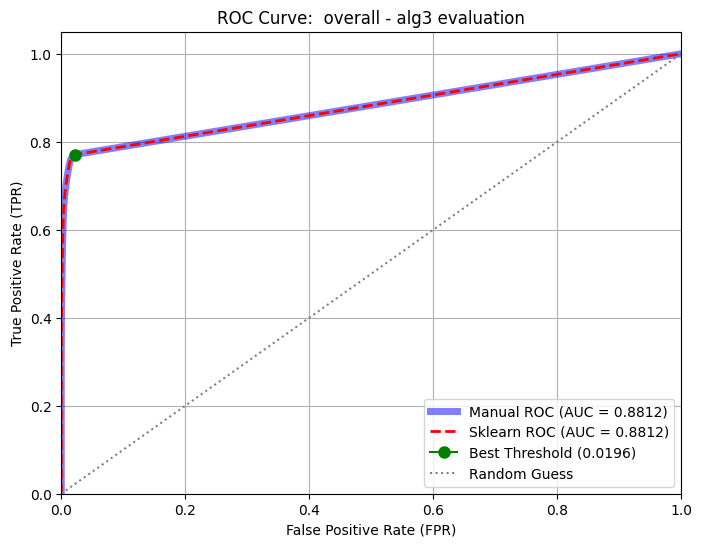

--------------- alg4 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg4 ---
Manual AUC: 0.8938
Sklearn AUC: 0.8938
Best Threshold: 0.0039


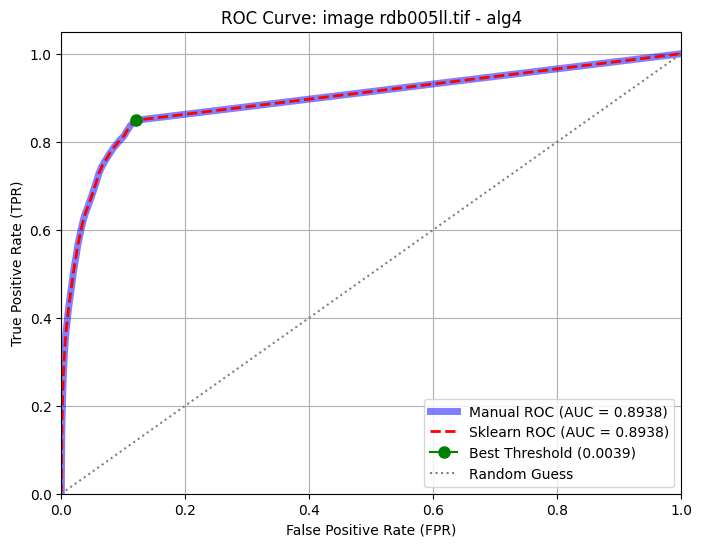

--- image rdb023ll.tif - alg4 ---
Manual AUC: 0.9581
Sklearn AUC: 0.9581
Best Threshold: 0.0510


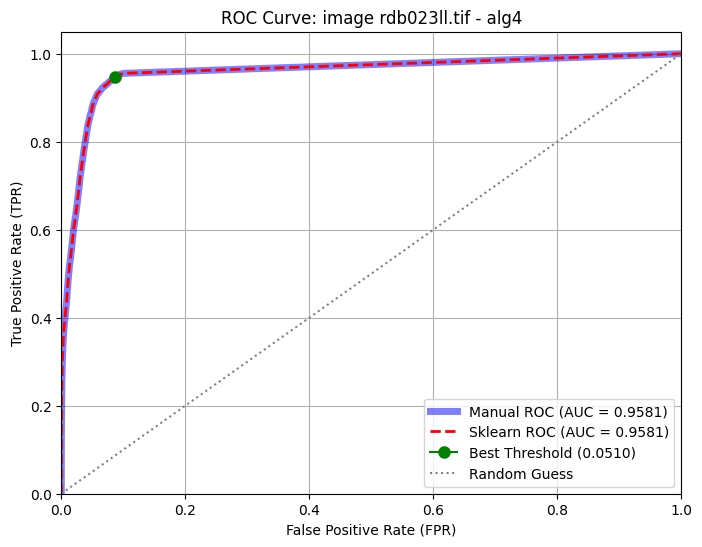

--- image rdb025ll.tif - alg4 ---
Manual AUC: 0.7433
Sklearn AUC: 0.7433
Best Threshold: 0.0039


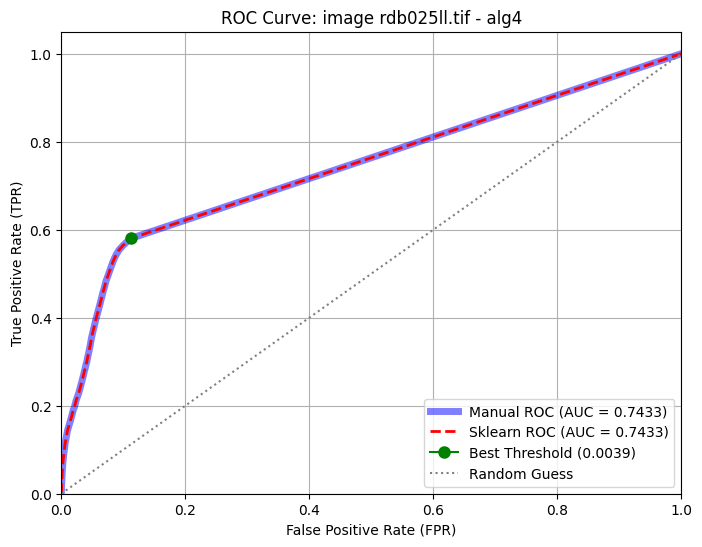

--- image rdb028rl.tif - alg4 ---
Manual AUC: 0.9623
Sklearn AUC: 0.9623
Best Threshold: 0.0039


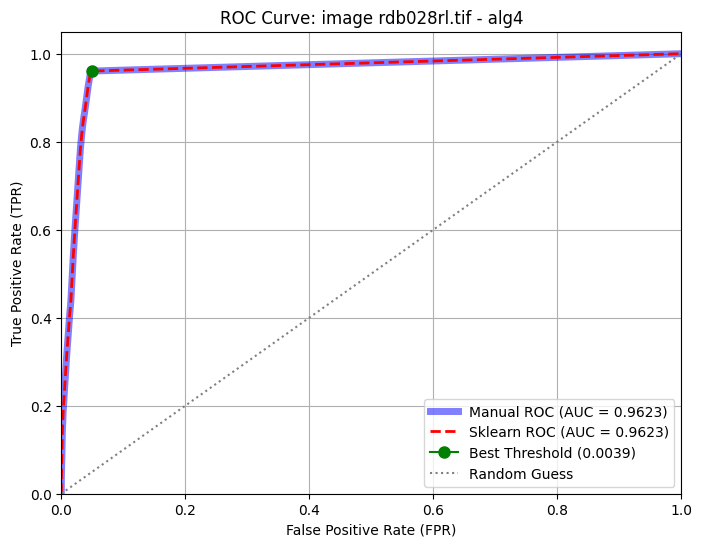

>>> per-algorithm evaluation for alg4 <<<

---  overall - alg4 evaluation ---
Manual AUC: 0.8619
Sklearn AUC: 0.8619
Best Threshold: 0.0039
Jaccard Index: 0.0877
Dice Coeffient: 0.1613


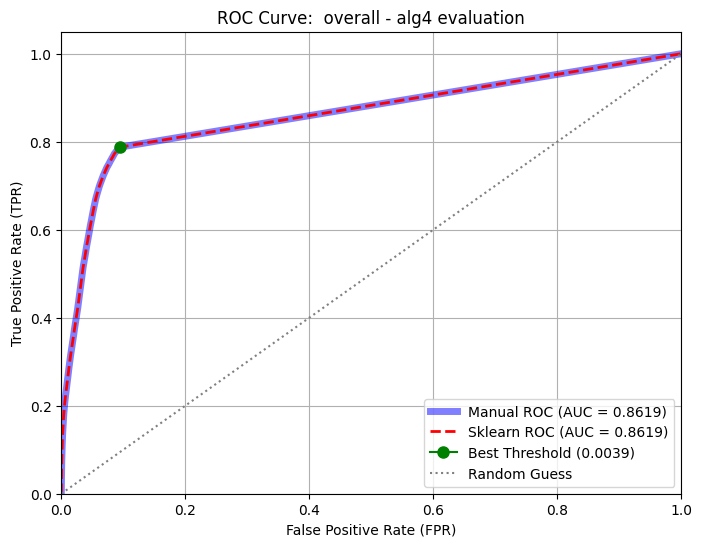

--------------- alg5 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg5 ---
Manual AUC: 0.7426
Sklearn AUC: 0.7426
Best Threshold: 0.2000


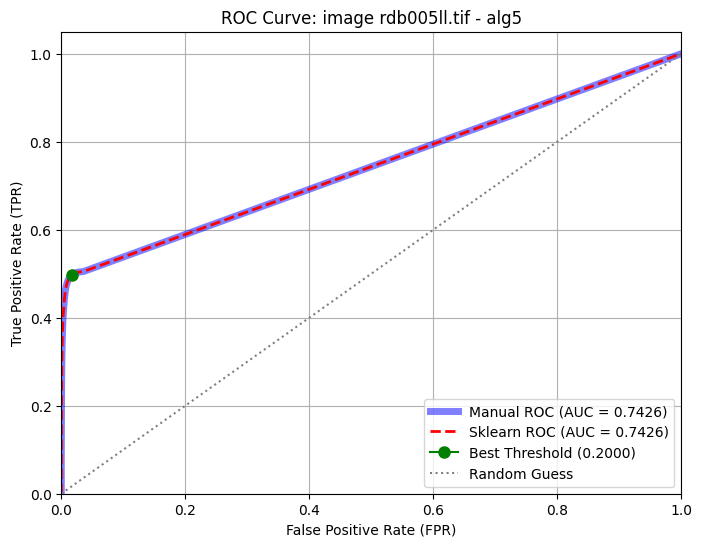

--- image rdb023ll.tif - alg5 ---
Manual AUC: 0.4837
Sklearn AUC: 0.4837
Best Threshold: 1.1000


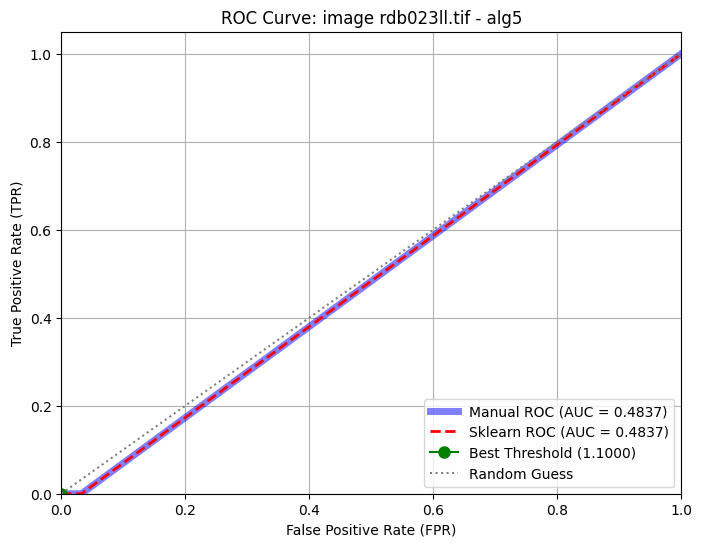

--- image rdb025ll.tif - alg5 ---
Manual AUC: 0.7543
Sklearn AUC: 0.7543
Best Threshold: 0.1412


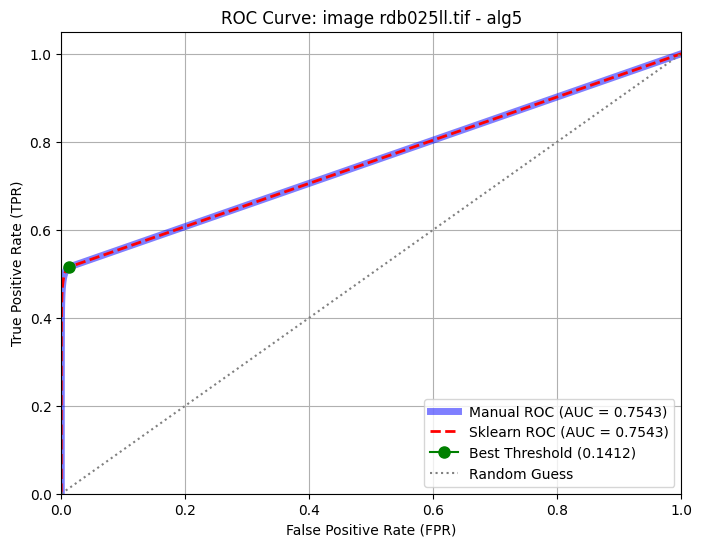

--- image rdb028rl.tif - alg5 ---
Manual AUC: 0.8002
Sklearn AUC: 0.8002
Best Threshold: 0.2784


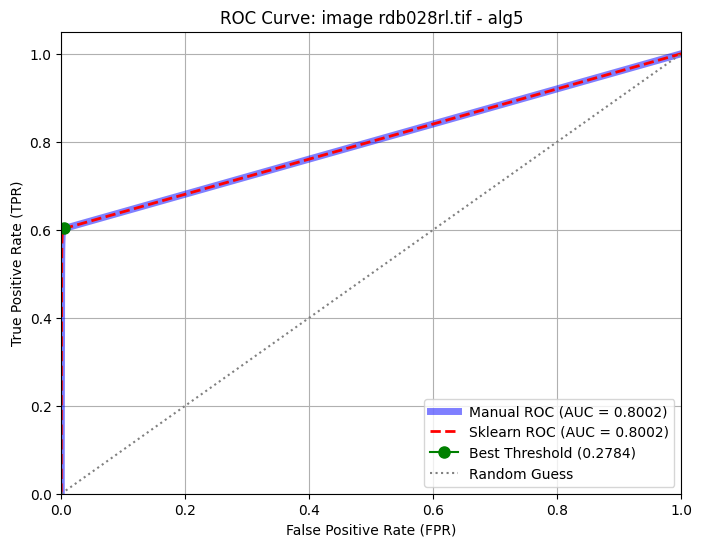

>>> per-algorithm evaluation for alg5 <<<

---  overall - alg5 evaluation ---
Manual AUC: 0.7405
Sklearn AUC: 0.7405
Best Threshold: 0.1804
Jaccard Index: 0.1920
Dice Coeffient: 0.3221


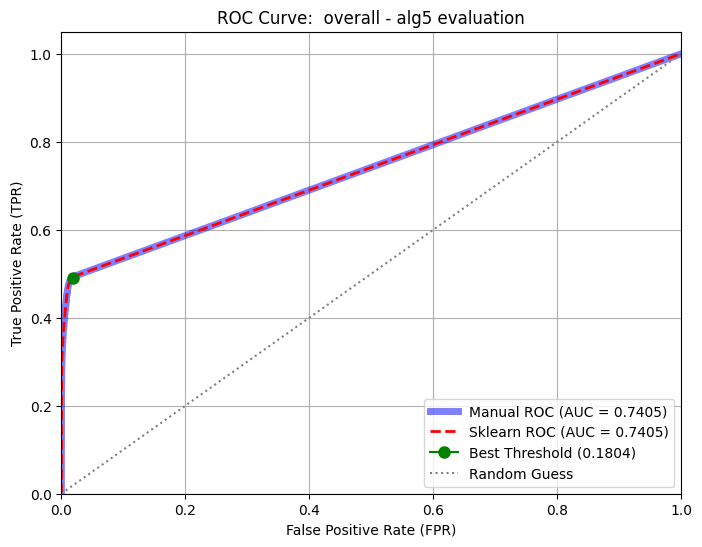

--------------- alg6 evaluation ---------------

>>> per-image evaluation <<<

--- image rdb005ll.tif - alg6 ---
Manual AUC: 0.9259
Sklearn AUC: 0.9259
Best Threshold: 0.0157


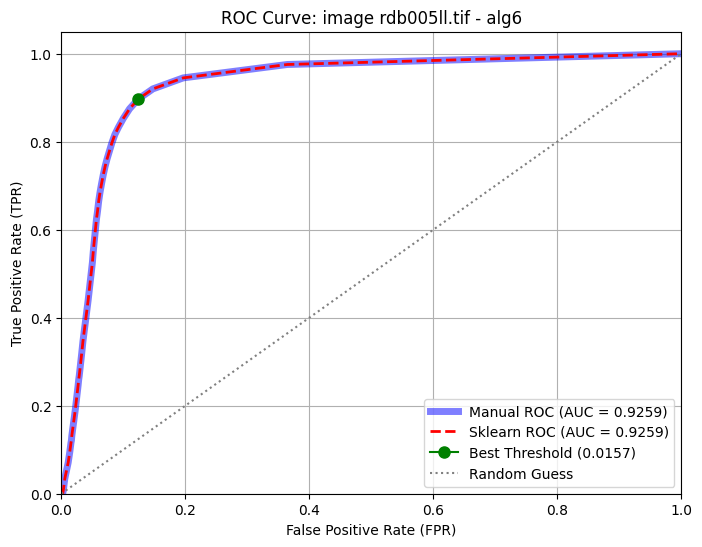

--- image rdb023ll.tif - alg6 ---
Manual AUC: 0.9187
Sklearn AUC: 0.9187
Best Threshold: 0.0196


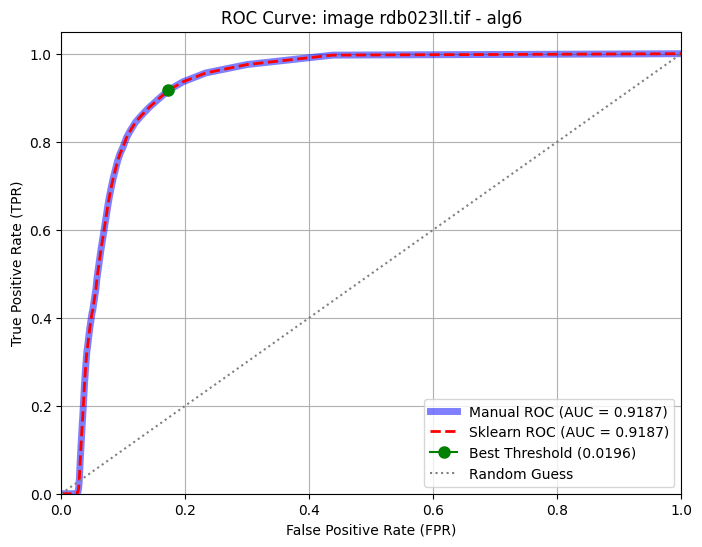

--- image rdb025ll.tif - alg6 ---
Manual AUC: 0.8811
Sklearn AUC: 0.8811
Best Threshold: 0.0275


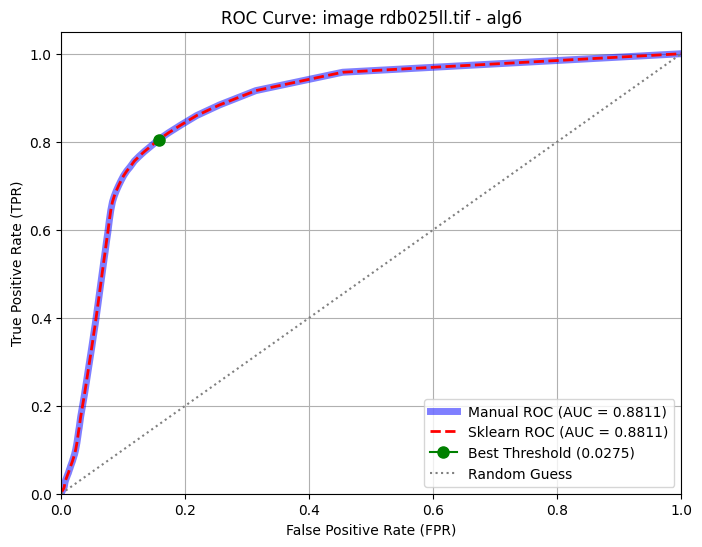

--- image rdb028rl.tif - alg6 ---
Manual AUC: 0.9087
Sklearn AUC: 0.9087
Best Threshold: 0.0196


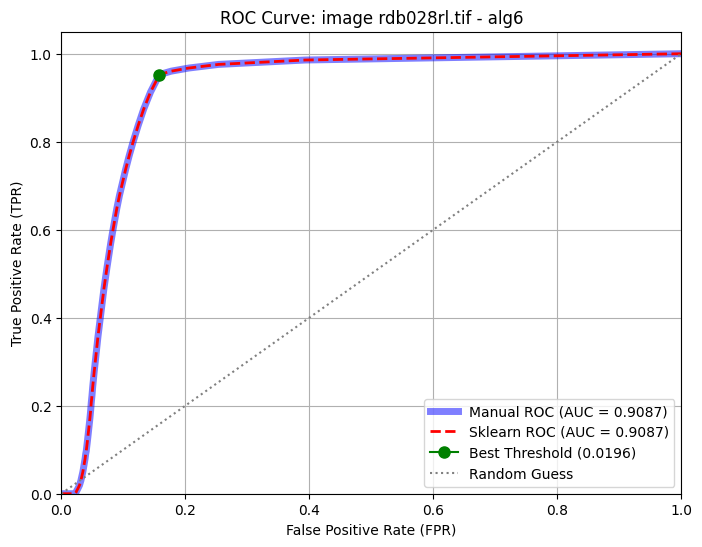

>>> per-algorithm evaluation for alg6 <<<

---  overall - alg6 evaluation ---
Manual AUC: 0.9044
Sklearn AUC: 0.9044
Best Threshold: 0.0196
Jaccard Index: 0.0625
Dice Coeffient: 0.1177


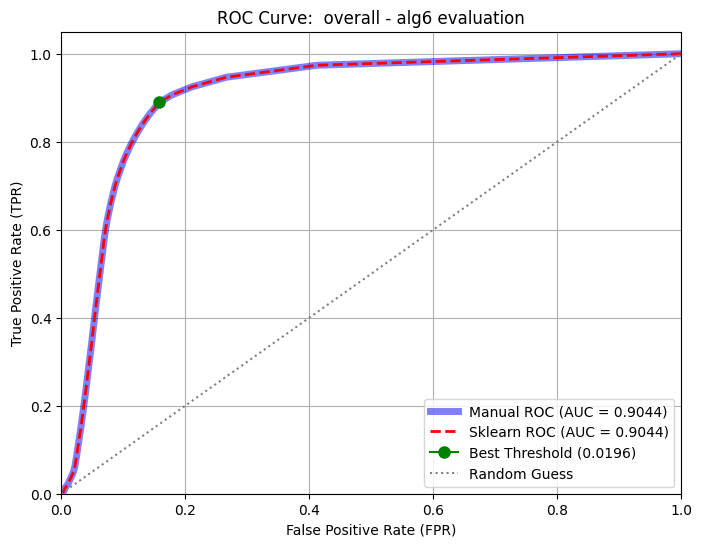

In [137]:
if os.path.exists(ALGO_DIR) and os.path.exists(GT_DIR):
    algorithms = [d for d in os.listdir(ALGO_DIR) if os.path.isdir(os.path.join(ALGO_DIR, d))]
    
    for algo_name in sorted(algorithms):
        algo_path = os.path.join(ALGO_DIR, algo_name)
        evaluate_algorithms(GT_DIR, algo_path, algo_name)